In [62]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from typing import Any

import numpy as np
import torch
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

from uqct.datasets.utils import get_dataset
from uqct.metrics import get_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
side_length=128

from uqct.models.unet import load_unet, predict

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
dataset = 'lung'
train_set, test_set = get_dataset(dataset, True)

In [50]:
images = torch.stack([
    test_set[i] for i in range(5)
]).to(device).unsqueeze(1)  # shape: (5, 1, 1, 128, 128)
images.shape

torch.Size([5, 1, 1, 256, 256])

In [51]:
from uqct.ct import (
    Experiment,
    Tomogram,
    anscombe_transform,
    compute_sinogram,
    fbp,
    fbp_ct,
    forward_ct,
    get_astra_geometry_3d,
    mse_ct,
    nll,
    sinogram_ct,
    uniform_allocation,
)

min/max of image 0: 0.0/0.49682772159576416
min/max of image 1: 0.0/0.7425925135612488
min/max of image 2: 0.0/0.5384037494659424
min/max of image 3: 0.0/0.5273841619491577
min/max of image 4: 0.0/1.0


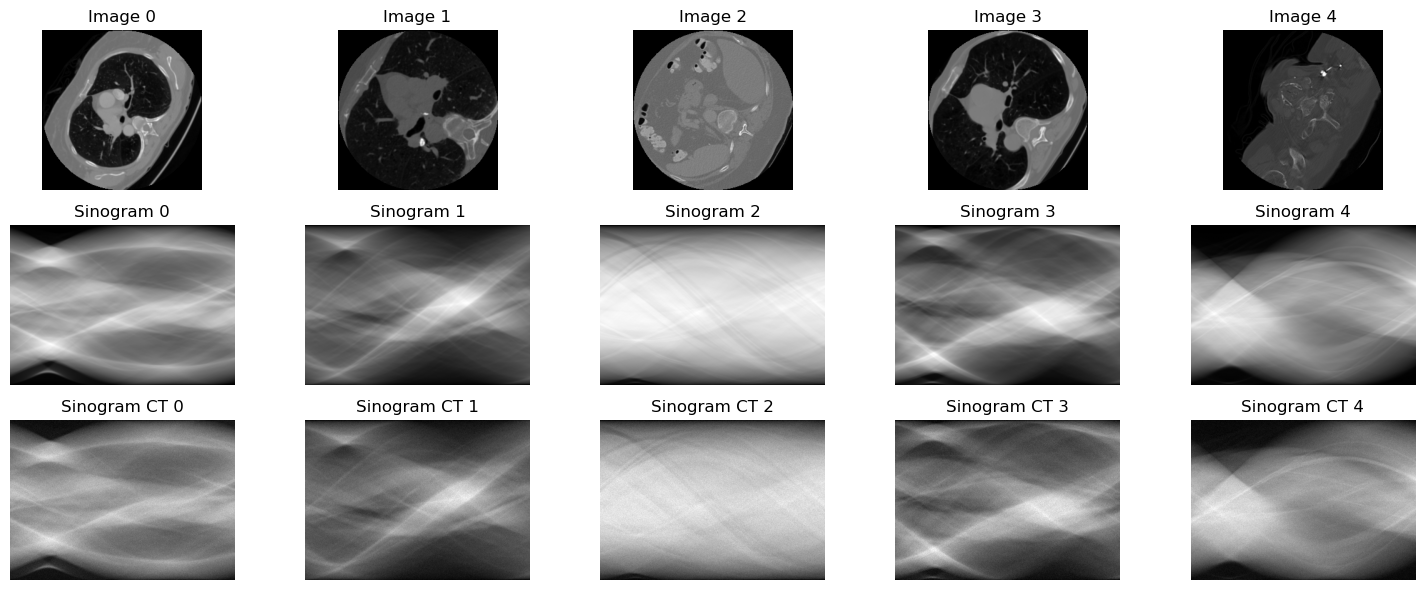

In [52]:
num_angles = 360
angles = torch.from_numpy(np.linspace(0, 180, num_angles, endpoint=False)).float()

# proj_geometry, vol_geometry = get_astra_geometry_3d(angles, 128, n_slices=5)
# print(vol_geometry)
# print(proj_geometry)


# t0 = time.time()
# for i in range(1000):
#     proj_geometry, vol_geometry = get_astra_geometry_3d(angles, images.shape[-1], n_slices=images.shape[0])
# print(f"Geometry setup time: {(time.time()-t0)/1000:.5f} seconds")

# def sinogram_astra(images, angles):
#     batch_dims = images.size()[:-2]
#     img_shape = images.size()[-2:]
#     images = images.view(-1, *img_shape)
    
#     proj_geometry, vol_geometry = get_astra_geometry_3d(angles, img_shape[0], n_slices=images.shape[0])
#     sinogram = compute_sinogram_astra(images, vol_geometry, proj_geometry)
#     return sinogram.view(*batch_dims, len(angles), img_shape[0])

sinogram = compute_sinogram(images, angles)

exposure, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=1e6)
measurements = forward_ct(images, angles, exposure=exposure)
measurements_sinogram = sinogram_ct(measurements, exposure)
experiment = Experiment(exposure, measurements, angles)


fig, axes = plt.subplots(3, len(images), figsize=(15, 6))
for i in range(len(images)):
    print(f"min/max of image {i}: {images[i].min().item()}/{images[i].max().item()}")
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[1, i].set_title(f'Sinogram {i}')
    axes[1, i].axis('off')

    axes[2, i].imshow(measurements_sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[2, i].set_title(f'Sinogram CT {i}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

sample 0: PSNR=22.990524291992188, min/max of FBP sample 0: 0.0/0.5169410705566406
sample 1: PSNR=25.68842315673828, min/max of FBP sample 1: 0.0/0.7071662545204163
sample 2: PSNR=21.570640563964844, min/max of FBP sample 2: 0.0/0.576382040977478
sample 3: PSNR=24.974140167236328, min/max of FBP sample 3: 0.0/0.5959382057189941
sample 4: PSNR=27.86138916015625, min/max of FBP sample 4: 0.0/1.0


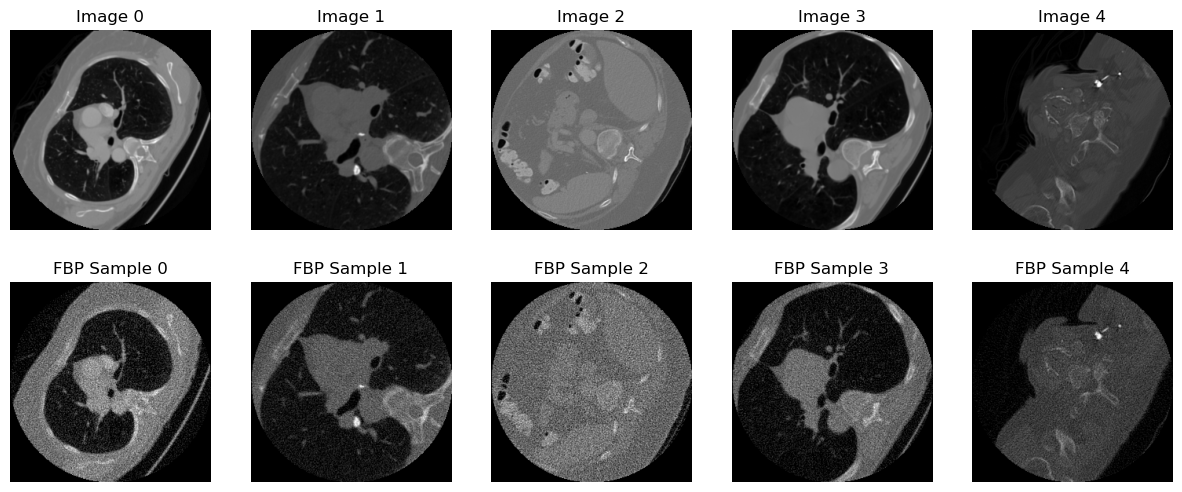

In [53]:
class FBPModel:
    def __init__(self, experiment, weighted=True):
        self.experiment = experiment
        self.weighted = weighted
    
    def sample(self):
        return fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=self.weighted)
    
fbp_model = FBPModel(experiment)

fbp_samples = fbp_model.sample()
fbp_samples.shape

fig, axes = plt.subplots(2, len(images), figsize=(15, 6))
for i in range(len(images)):
    metrics = get_metrics(fbp_samples[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {fbp_samples[i].min().item()}/{fbp_samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(fbp_samples[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'FBP Sample {i}')
    axes[1, i].axis('off')

Iterative Reconstruction:   0%|          | 0/1000 [00:00<?, ?it/s]

sample 0: PSNR=19.26146697998047, min/max of FBP sample 0: 0.0/0.8860353231430054
sample 1: PSNR=20.78485107421875, min/max of FBP sample 1: 0.0/0.9475057721138
sample 2: PSNR=16.942373275756836, min/max of FBP sample 2: 0.0/0.9668509364128113
sample 3: PSNR=19.589847564697266, min/max of FBP sample 3: 0.0/0.7835186719894409
sample 4: PSNR=19.3199405670166, min/max of FBP sample 4: 0.0/1.0


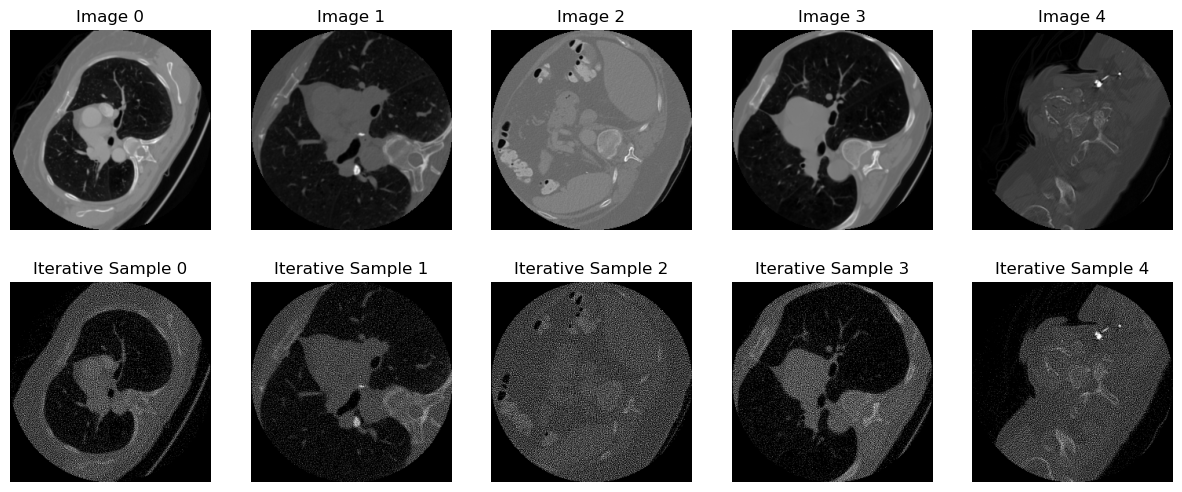

In [54]:
def get_circle_mask(im_size, device):
    circle_mask = torch.ones((im_size, im_size), device=device)
    radius = im_size // 2
    y, x = torch.meshgrid(torch.arange(im_size, device=device),
                          torch.arange(im_size, device=device),
                          indexing='ij')
    mask = (x - radius) ** 2 + (y - radius) ** 2 <= radius ** 2
    circle_mask[~mask] = 0
    return circle_mask

class IterativeModel:
    def __init__(self, experiment, steps=10, init_method='fbp', use_sigmoid=False, lr=1e-1, prior=None, loss = 'nll'):
        self.experiment = experiment
        self.steps = steps
        self.init_method = init_method
        self.use_sigmoid = use_sigmoid
        self.lr = lr
        self._prior = prior
        self.loss = loss

    def prior(self):
        if self.init_method == 'fbp':
            prior = fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=False)
        elif self.init_method == 'fbp_weighted':
            prior = fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=True)
        elif self.init_method == 'zeros':
            prior = torch.zeros((*measurements.shape[:-2], measurements.shape[-1], measurements.shape[-1]), device=measurements.device)
        elif self.init_method == 'random':
            bs = self.experiment.measurements.shape[0:-2]
            prior = torch.randn((*bs, self.experiment.measurements.shape[-1], self.experiment.measurements.shape[-1]), device=self.experiment.measurements.device)
        elif self.init_method == 'prior':
            prior = self._prior.clone()
        return prior

    def sample(self):
        tomogram = Tomogram(prior=self.prior().detach(), use_sigmoid=self.use_sigmoid)

        optimizer = torch.optim.Adam(tomogram.parameters(), lr=self.lr)
        if self.loss == 'nll':
            loss_fn = nll

        else:
            def loss_fn(recon, meas, angles, alloc):
                return mse_ct(recon, meas, angles, alloc, vst=anscombe_transform)

        circle_mask = get_circle_mask(tomogram().shape[-1], device=tomogram.image.device)

        it = tqdm(range(self.steps), desc="Iterative Reconstruction")
        for step in it:
            optimizer.zero_grad()
            loss = loss_fn(tomogram(), self.experiment.measurements, self.experiment.exposure, self.experiment.angles).mean()
            # print(loss)
            loss.backward()
            optimizer.step()

          # circle mask and clamp
            with torch.no_grad():
                tomogram.image.clamp_(min=0, max=1)
                tomogram.image.mul_(circle_mask)
                # print(tomogram.image.min(), tomogram.image.max())

            it.set_postfix(loss=f"{loss.item():.10f}")

        with torch.no_grad():
            recon = tomogram()

        # recon = torch.clamp(recon, min=0, max=1)
        return recon
    
iterative_model = IterativeModel(experiment, steps=1000, use_sigmoid=False, init_method='fbp', lr=1e-2)
samples = iterative_model.sample().detach()


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    metrics = get_metrics(samples[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {samples[i].min().item()}/{samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(samples[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Iterative Sample {i}')
    axes[1, i].axis('off')

plt.show()


In [55]:
# ckpt_path = '/mydata/chip/shared/checkpoints/uqct/unet_dense_128_lamino_0.pt'
ckpt_path = Path('/mydata/chip/shared/checkpoints/uqct/unet_dense_128_lung_0.pt')
if not ckpt_path.exists():
    ckpt_path = Path("../checkpoints/unet_dense/unet_dense_128_lung_0.pt")

# Load model
unet = load_unet(ckpt_path, sparse=False).to(device)  # type: ignore
unet.eval()


Loaded checkpoint: epoch=124, val_loss=0.000284077187879356


UNet2DModel(
  (conv_in): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.37, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Co

torch.Size([5, 256, 256])
torch.Size([5, 200, 256]) torch.Size([5, 1, 1])
torch.Size([5, 128, 128]) torch.Size([5, 1, 1])
MSE: 7.331208325922489e-05


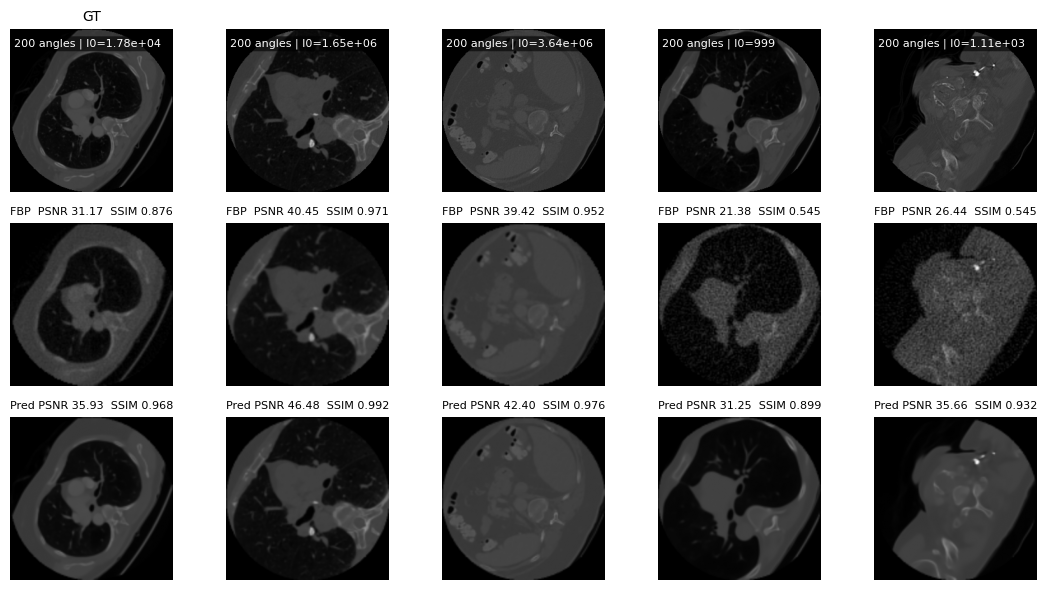

In [56]:

import torch.nn.functional as F

from uqct.ct import AstraParallelOp3D

xs = images.squeeze()
N_ANGLES = 200
num_examples = xs.shape[0]


# Geometry & projector (reuse training)
angles = torch.from_numpy(np.linspace(0, 180, N_ANGLES, endpoint=False))
proj_geom_hr, vol_geom_hr = get_astra_geometry_3d(angles, 256, num_examples)
proj_geom_lr, vol_geom_lr = get_astra_geometry_3d(angles, 128, num_examples)
op = AstraParallelOp3D(proj_geom_hr, vol_geom_hr)

from uqct.training.unet import sample_fbp_dense  # forward -> Poisson -> bin -> FBP (LR)

print(xs.shape)
fbp_lr, I0_lr = sample_fbp_dense(
        xs, op, proj_geom_lr, vol_geom_lr, device
    )  # (N,128,128), (N,1,1)
n_angles_disp = torch.full((num_examples,), N_ANGLES, device=device)

# Class labels only if using sparse_model (as in training)
class_labels = None

print(fbp_lr.shape, I0_lr.shape)

preds_lr = predict(
    unet,
    fbp_lr,
    I0_lr,
    class_labels=class_labels,
)  # (N,128,128)

# Prepare for plotting (uniform 256×256 display)
gt = xs.squeeze(1).clamp(0, 1).detach().cpu()  # (N,256,256)
fbp_up = (
    F.interpolate(
        fbp_lr.unsqueeze(1), size=(256, 256), mode="bilinear", align_corners=False
    )
    .squeeze(1)
    .clamp(0, 1)
    .cpu()
)
pred_up = (
    F.interpolate(
        preds_lr.unsqueeze(1), size=(256, 256), mode="bilinear", align_corners=False
    )
    .squeeze(1)
    .clamp(0, 1)
    .cpu()
)

# ---- Metrics at native 128×128 resolution ----
gt_lr = (
    F.interpolate(gt.unsqueeze(1), size=(128, 128), mode="area")
    .squeeze(1)
    .to(fbp_lr.device)
)  # match FBP/Pred resolution
mse = F.mse_loss(gt_lr, preds_lr)
print(f"MSE: {mse}")

fbp_metrics = []
pred_metrics = []
for i in range(num_examples):
    m_fbp = get_metrics(gt_lr[i], fbp_lr[i], normalize_range=True, constrained=True)
    m_pred = get_metrics(
        gt_lr[i], preds_lr[i], normalize_range=True, constrained=True
    )
    fbp_metrics.append(m_fbp)
    pred_metrics.append(m_pred)

# Values for overlay: angles (int) and I0 per sample (float)
n_angles_np = n_angles_disp.detach().float().cpu().numpy()
I0_vals = I0_lr.detach().float().view(num_examples, -1).mean(dim=1).cpu().numpy()

# Plot: 3 rows (GT / FBP / Pred) × N columns, show PSNR & SSIM on each column
_, axes = plt.subplots(3, num_examples, figsize=(2.2 * num_examples, 6.0))
if num_examples == 1:
    axes = np.asarray(axes).reshape(3, 1)

for i in range(num_examples):
    # GT + overlay with angles and I0
    axes[0, i].imshow(gt[i], cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("GT", fontsize=10)

    # Overlay text (top-left)
    overlay_txt = f"{int(round(n_angles_np[i]))} angles | I0={I0_vals[i]:.3g}"
    axes[0, i].text(
        6,
        14,
        overlay_txt,
        color="white",
        fontsize=8,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6),
    )

    # FBP + metrics
    axes[1, i].imshow(fbp_up[i], cmap="gray", vmin=0.0, vmax=1.0)
    axes[1, i].axis("off")
    axes[1, i].set_title(
        f"FBP  PSNR {fbp_metrics[i]['PSNR']:.2f}  SSIM {fbp_metrics[i]['SS']:.3f}",
        fontsize=8,
    )

    # Pred + metrics
    axes[2, i].imshow(pred_up[i], cmap="gray", vmin=0.0, vmax=1.0)
    axes[2, i].axis("off")
    axes[2, i].set_title(
        f"Pred PSNR {pred_metrics[i]['PSNR']:.2f}  SSIM {pred_metrics[i]['SS']:.3f}",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

In [65]:
from uqct.ct import poisson


def sample_obs_dense(
    x: torch.Tensor,
    op: AstraParallelOp3D,
    proj_geom_lr: dict[str, Any],
    vol_geom_lr: dict[str, dict],
    I_tot: torch.Tensor,
    device: torch.device,
    l = 5,
):
    I_0 = I_tot.view(-1, 1, 1) / N_ANGLES / 2  # divide by 2 since we simulate at higher resolution
    scale = l / x.shape[-1]
    radon = op.forward(x.squeeze(1))
    counts = poisson(I_0 * torch.exp(-scale * radon))  # (B, 200, 256)
    counts_lr = counts.view(counts.shape[0], counts.shape[1], 128, 2).sum(
        -1
    )  # (B, 200, 128)
    # I_0_lr = I_0 * 2
    # sino = sinogram_ct(counts_lr, I_0_lr, L).clip(0)
    # fbp = iradon_astra(sino.transpose(1, 2), vol_geom_lr, proj_geom_lr).clip(0, 1)
    return counts_lr
    
schedule = 1e4 * 2 ** torch.arange(10, device=device).float()  # 10 levels from 10k to ~10M
# schedule = torch.ones(50, device=device).float() * 1e4 / 5

schedule[0] = 1e4

data = torch.stack([sample_obs_dense(
    xs,
    op,
    proj_geom_lr,
    vol_geom_lr,
    I_tot,
    device
) for I_tot in schedule])


data.shape

torch.Size([10, 5, 200, 128])

In [66]:
predictions = {
    'fbp': [],
    'unet': [],
}
L = 5
from uqct.ct import AstraParallelOp3D, get_astra_geometry_3d, iradon_astra, sinogram_ct

for I_tot, counts in zip(schedule.cumsum(dim=0), data.cumsum(dim=0)):
    I_0 = I_tot.view(-1, 1, 1) / counts.shape[-2]  # uniform allocation
    sino = sinogram_ct(counts, I_0, L).clip(0)
    fbp = iradon_astra(sino.transpose(1, 2), vol_geom_lr, proj_geom_lr).clip(0, 1)

    pred = predict(unet, fbp, I_0.unsqueeze(1), class_labels=None).squeeze(1).clip(0, 1)
    predictions['fbp'].append(fbp)
    predictions['unet'].append(pred)

predictions['fbp'] = torch.stack(predictions['fbp'])
predictions['unet'] = torch.stack(predictions['unet'])


In [ ]:
angles.shape

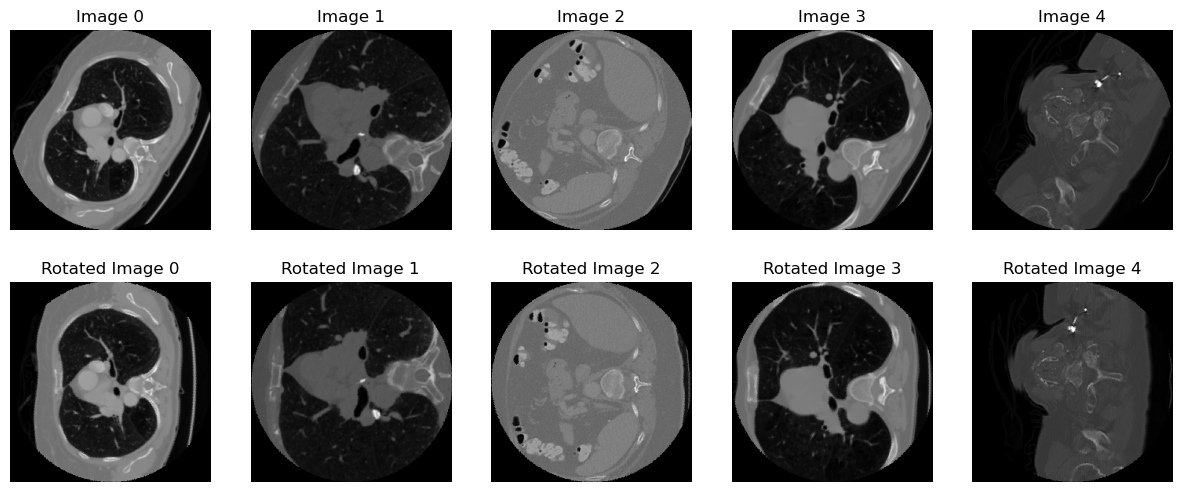

In [67]:
import torchvision.transforms.functional as TF

degree = 30

def rotate_images(images, degree):
    return torch.vmap(lambda img: TF.rotate(img, degree))(images)

rotated_images = rotate_images(images, degree)
fig, axes = plt.subplots(2, len(images), figsize=(15, 6))
for i in range(len(images)):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(rotated_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Rotated Image {i}')
    axes[1, i].axis('off')

In [ ]:
gt.shape, images.shape

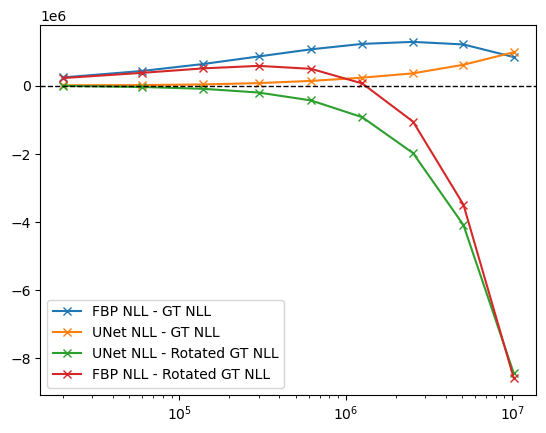

In [123]:
import torch.nn.functional as F

gt_lr = (
    F.interpolate(gt.unsqueeze(1), size=(128, 128), mode="area")
    .squeeze(1)
    .to(fbp_lr.device)
)  # match FBP/Pred resolution

gt_rotated = rotate_images(gt.unsqueeze(1), 30).squeeze(1)
gt_lr_rotated = (
    F.interpolate(gt_rotated.unsqueeze(1), size=(128, 128), mode="area")
    .squeeze(1)
    .to(fbp_lr.device)
)  # match FBP/Pred resolution

# deg = 4
# gt_lr_rotated = (
#     F.
#     .F.interpolate(gt.unsqueeze(1), size=(128, 128), mode="area")
#     .squeeze(1)
#     .to(fbp_lr.device)
# )  #

# print(predictions['fbp'][:-1].shape, data[1:].shape, schedule[1:].view(-1,1,1).shape, angles.shape)
# print(predictions['unet'][:-1].shape)
intensities_nll = schedule[1:].view(-1, 1, 1, 1) / data.shape[-2]

nll_fbp = nll(predictions['fbp'][:-1], data[1:], intensities_nll, angles).sum((-1,-2))
nll_gt = nll(gt_lr, data[1:], intensities_nll, angles).sum((-1,-2))
nll_unet = nll(predictions['unet'][:-1].float(), data[1:], intensities_nll, angles).sum((-1, -2))

nll_gt_rotated = nll(gt_lr_rotated, data[1:], intensities_nll, angles).sum((-1,-2))
plt.plot(schedule[1:].cumsum(dim=0).cpu(), (nll_fbp[:, 0] - nll_gt[:, 0]).cumsum(dim=0).cpu(), marker='x', label='FBP NLL - GT NLL')
plt.plot(schedule[1:].cumsum(dim=0).cpu(), (nll_unet[:,0] - nll_gt[:, 0]).cumsum(dim=0).cpu(), marker='x', label='UNet NLL - GT NLL')
plt.plot(schedule[1:].cumsum(dim=0).cpu(), (nll_unet[:, 0] - nll_gt_rotated[:, 0]).cumsum(dim=0).cpu(), marker='x', label='UNet NLL - Rotated GT NLL')
plt.plot(schedule[1:].cumsum(dim=0).cpu(), (nll_fbp[:, 0] - nll_gt_rotated[:, 0]).cumsum(dim=0).cpu(), marker='x', label='FBP NLL - Rotated GT NLL')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.legend()

plt.xscale('log')
# plt.yscale('log')

torch.Size([5, 128, 128]) torch.Size([10, 5, 128, 128])


/tmp/ipykernel_225042/2901107985.py:2: UserWarning: Using a target size (torch.Size([1, 5, 128, 128])) that is different to the input size (torch.Size([10, 5, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return torch.sqrt(F.mse_loss(predictions, gt, reduction='none').mean(dim=(-1, -2)))


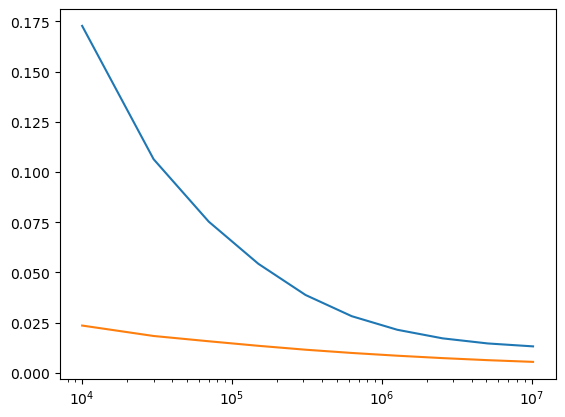

In [124]:
def rmse(predictions, gt):
    return torch.sqrt(F.mse_loss(predictions, gt, reduction='none').mean(dim=(-1, -2)))

gt_lr = (
    F.interpolate(gt.unsqueeze(1), size=(128, 128), mode="area")
    .squeeze(1)
    .to(fbp_lr.device)
)  # match FBP/Pred resolution

print(gt_lr.shape, predictions['fbp'].shape)

plt.plot(schedule.cumsum(dim=0).cpu(), rmse(predictions['fbp'], gt_lr.unsqueeze(0)).mean(dim=-1).cpu(), label='FBP')
plt.plot(schedule.cumsum(dim=0).cpu(), rmse(predictions['unet'], gt_lr.unsqueeze(0)).mean(dim=-1).cpu(), label='unet')

plt.xscale('log')

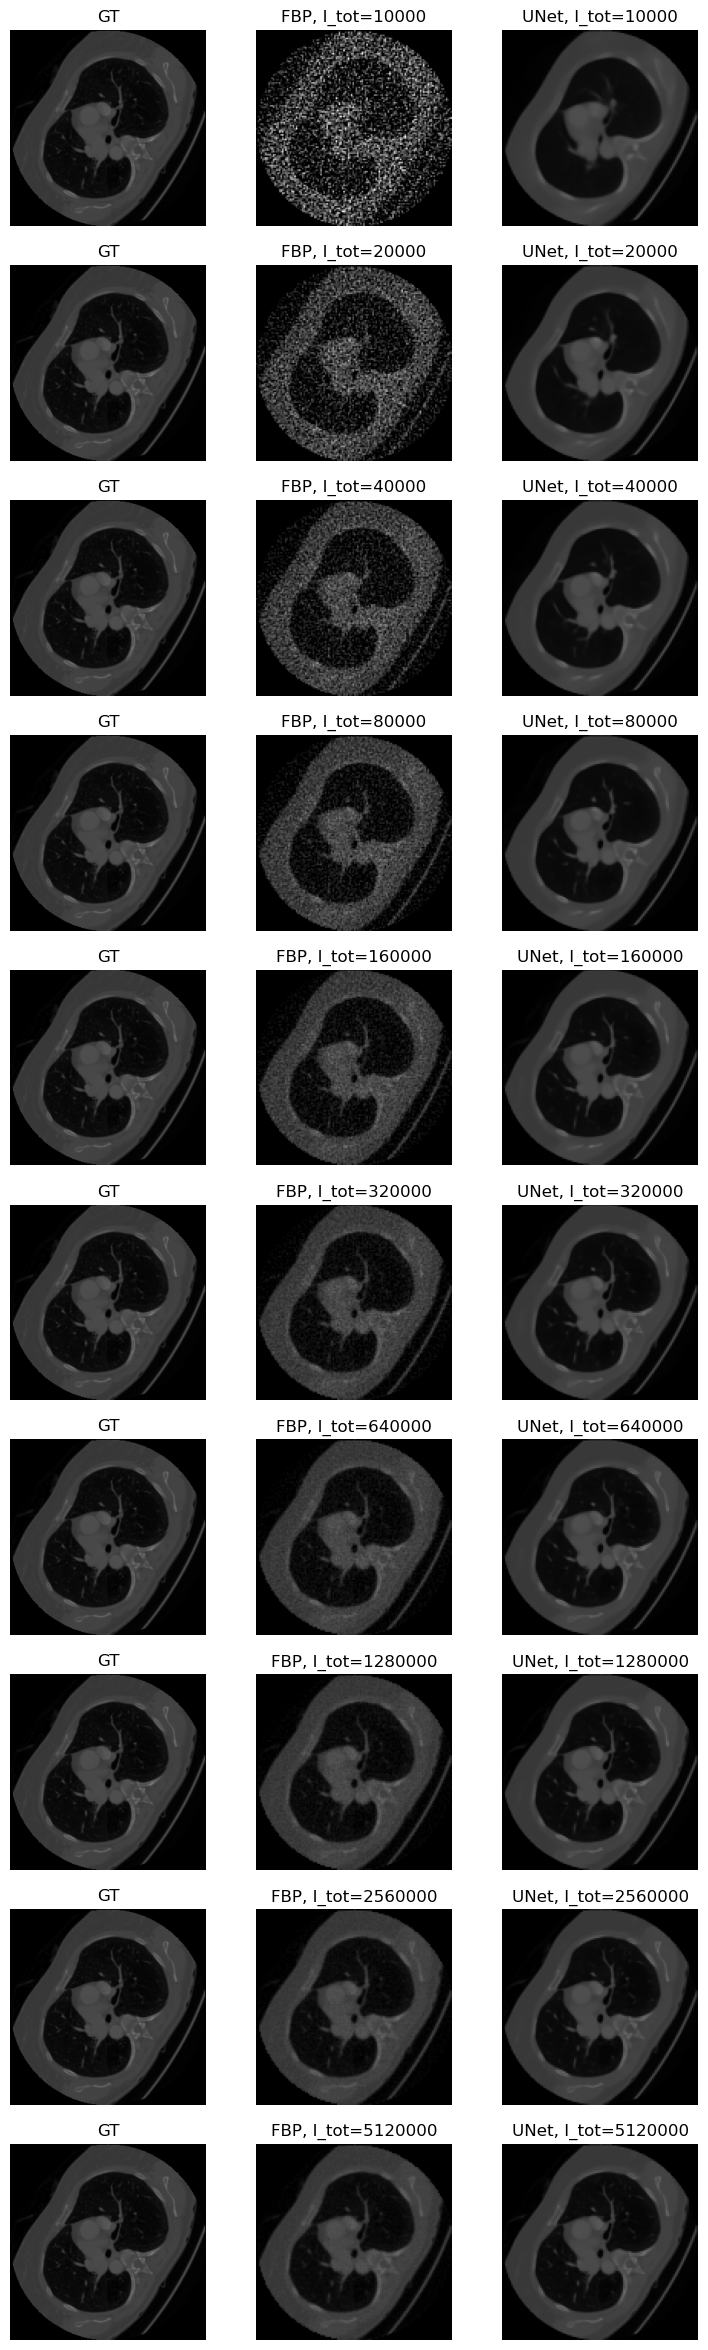

In [125]:
fig, axes = plt.subplots(len(schedule), 3, figsize=(9, 3 * len(schedule)))

for i, I_tot in enumerate(schedule):
    axes[i, 0].imshow(xs[0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title('GT')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(predictions['fbp'][i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f'FBP, I_tot={I_tot.item():.0f}')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(predictions['unet'][i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f'UNet, I_tot={I_tot.item():.0f}')
    axes[i, 2].axis('off')
